# $\mathrm{Tests}$

## $\mathrm{Loss~Function}$

In [1]:
import Pk_from_snaps as pkmod
import numpy as np
import matplotlib.pyplot as plt

In [2]:
realization = 0
BoxSize = 1000
model = 'fR_p'

In [3]:
# Paths for Quijote
root_quijote = f'/data/jborjuel/data/Snapshots/{model}'
path_ICs_quij = f"{root_quijote}/{realization}/ICs/ics"
path_snaps_quij = f"{root_quijote}/{realization}/snapdir_004/snap_004"

# Paths for COLA
root_cola = f'/data/jborjuel/sims/fR/{model}/'
path_ICs_cola = f"{root_cola}/{model}_{realization}/{model}_{realization}_z127p000"
path_snaps_cola = f"{root_cola}/{model}_{realization}/{model}_{realization}_z0p000"

# Load positions
pos_i_cola, pos_f_cola = pkmod.sort_pos(path_ICs_cola, path_snaps_cola, Quijote=False)
pos_i_quij, pos_f_quij = pkmod.sort_pos(path_ICs_quij, path_snaps_quij, Quijote=True)

# Compute power spectra
k_quij, Pk_quij = pkmod.Pk(positions=pos_f_quij.astype(np.float32), Quijote=False)
k_cola, Pk_cola = pkmod.Pk(positions=pos_f_cola.astype(np.float32), Quijote=False)

In [4]:
# Load VNet correction: l = 1
path_vnet_l1 = f'/data/mrhurtad/bayron-proj/tests_m2m/bpT/l1/vnet_orig/vnet_{model}_{realization}.npy'
disp_vnet_l1 = np.load(path_vnet_l1).reshape(3, -1).T

# Compute final positions
pos_f_vnet_l1 = ((disp_vnet_l1 + pos_i_cola) % BoxSize).astype(np.float32)

# Compute spectra
k, Pk_l1 = pkmod.Pk(positions=pos_f_vnet_l1, Quijote=False)

In [5]:
# Load VNet correction: l = 2
path_vnet_l2 = f'/data/mrhurtad/bayron-proj/tests_m2m/bpT/l2/vnet_orig/vnet_{model}_{realization}.npy'
disp_vnet_l2 = np.load(path_vnet_l2).reshape(3, -1).T

# Compute final positions
pos_f_vnet_l2 = ((disp_vnet_l2 + pos_i_cola) % BoxSize).astype(np.float32)

# Compute spectra
k, Pk_l2 = pkmod.Pk(positions=pos_f_vnet_l2, Quijote=False)

In [6]:
# Load VNet correction: l = 3
path_vnet_l3 = f'/data/mrhurtad/bayron-proj/tests_m2m/bpT/l3/vnet_orig/vnet_{model}_{realization}.npy'
disp_vnet_l3 = np.load(path_vnet_l3).reshape(3, -1).T

# Compute final positions
pos_f_vnet_l3 = ((disp_vnet_l3 + pos_i_cola) % BoxSize).astype(np.float32)

# Compute spectra
k, Pk_l3 = pkmod.Pk(positions=pos_f_vnet_l3, Quijote=False)

In [7]:
# Load VNet correction (nuevo esquema de nombres)
path_vnet_MG = f'/data/mrhurtad/bayron-proj/tests_m2m/bpT/MG-SRNet/vnet_{model}_{realization}.npy'
disp_vnet_MG = np.load(path_vnet_MG).reshape(3, -1).T

# Compute quasi-particles
pos_f_vnet_MG = ((disp_vnet_MG + pos_i_cola) % BoxSize).astype(np.float32)

# Compute spectra
k, Pk_MG = pkmod.Pk(positions=pos_f_vnet_MG, Quijote=False)

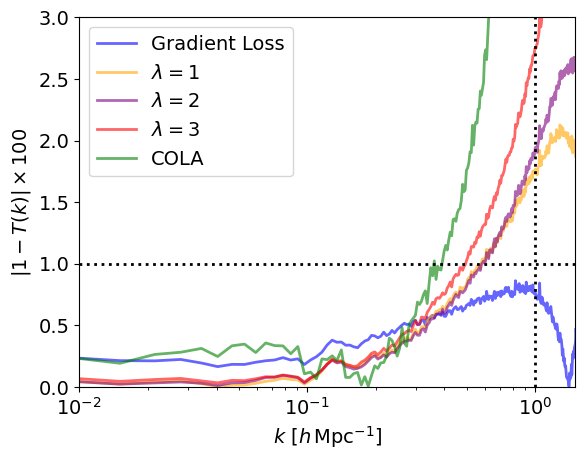

In [52]:
# --- Accuracy ---
plt.xlim(1e-2, 1.5)
plt.ylim(0, 3)
plt.xlabel(r'$k\ [h \, {\rm Mpc}^{-1}]$', fontsize=14)
plt.ylabel(r'$|1 - T(k)| \times 100$', fontsize=14)

# Add to plot
plt.semilogx(k, np.abs(1 - (Pk_MG / Pk_quij)) * 100, color='blue', alpha=0.6, lw=2, label='Gradient Loss')
plt.semilogx(k, np.abs(1 - (Pk_l1 / Pk_quij)) * 100, color='orange', alpha=0.6, lw=2, label=r'$\lambda = 1$')
plt.semilogx(k, np.abs(1 - (Pk_l2 / Pk_quij)) * 100, color='purple', alpha=0.6, lw=2, label=r'$\lambda = 2$')
plt.semilogx(k, np.abs(1 - (Pk_l3 / Pk_quij)) * 100, color='red', alpha=0.6, lw=2, label=r'$\lambda = 3$')
plt.semilogx(k, np.abs(1 - (Pk_cola / Pk_quij)) * 100, color='green', alpha=0.6, lw=2, label='COLA')
plt.axvline(1.0, color='black', lw=2, ls=':')
plt.axhline(1.0, color='k', lw=2, ls=':')

plt.legend(fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.savefig("Ablation_Acc.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [46]:
acc_MG = np.mean(np.abs(1 - (Pk_MG[0:238] / Pk_quij[0:238]))*100)
acc_l1 = np.mean(np.abs(1 - (Pk_l1[0:238] / Pk_quij[0:238]))*100)
acc_l2 = np.mean(np.abs(1 - (Pk_l2[0:238] / Pk_quij[0:238]))*100)
acc_l3 = np.mean(np.abs(1 - (Pk_l3[0:238] / Pk_quij[0:238]))*100)
acc_cola = np.mean(np.abs(1 - (Pk_cola[0:238] / Pk_quij[0:238]))*100)
acc_MG, acc_l1, acc_l2, acc_l3, acc_cola

(0.5442123592836989,
 1.2249806259836526,
 1.3706033357408944,
 1.9880397124392353,
 6.887012898420862)

## $\mathrm{Displacement~Field}$

In [1]:
import numpy as np
import readgadget
import matplotlib.pyplot as plt
import Pk_from_snaps as pkmod

In [2]:
boxsize     = 1000.0                  #--Full box edge length
grid        = 512
subboxsize  = 250                     #--Subbox edge length
subboxes    = int(boxsize/subboxsize) #--Subboxes along one dimension.
resolution  = int(grid/subboxes)      #--Particles along one dimension. 
subboxes, resolution

(4, 128)

In [3]:
realization = 0
#QUIJOTE
root_quijote = f"/data/jborjuel/data/Snapshots/fR_p/{realization}"
# Path to ICs 
path_ICs_quij = f"{root_quijote}/ICs/ics"
# Path to snapshot at z = 0
path_snaps_quij = f"{root_quijote}/snapdir_004/snap_004"

# COLA
root_cola = "/data/jborjuel/sims/fR/fRemu_p"
# Path to ICs from cola at z = 127
path_ICs_cola = f"{root_cola}/fRemu_p_z127p000"
# Path to snapshot at z = 0
path_snaps_cola = f"{root_cola}/fRemu_p_z0p000"

# Load VNet Displacement
root_vnet = f'/data/mrhurtad/bayron-proj/tests_m2m/bpT/MG-SRNet/vnet_fR_p_{realization}.npy'
disp_vnet = np.load(root_vnet).reshape(3, -1).T

In [4]:
# QUIJOTE
ids_i_quij  = readgadget.read_block(path_ICs_quij, "ID  ", ptype=[1])-1
pos_i_quij  = readgadget.read_block(path_ICs_quij, "POS ", ptype=[1])/1e3
# Sorted Quijote initial positions 
pos_i_quij = pos_i_quij[np.argsort(ids_i_quij)]

ids_f_quij  = readgadget.read_block(path_snaps_quij, "ID  ", ptype=[1])-1
pos_f_quij  = readgadget.read_block(path_snaps_quij, "POS ", ptype=[1])/1e3
# Sorted Quijote final positions 
pos_f_quij = pos_f_quij[np.argsort(ids_f_quij)] 

# COLA
ids_i_cola  = readgadget.read_block(path_ICs_cola, "ID  ", ptype=[1])
pos_i_cola  = readgadget.read_block(path_ICs_cola, "POS ", ptype=[1])
# Sorted cola initial positions 
pos_i_cola  = pos_i_cola[np.argsort(ids_i_cola)]

ids_f_cola  = readgadget.read_block(path_snaps_cola, "ID  ", ptype=[1])
pos_f_cola  = readgadget.read_block(path_snaps_cola, "POS ", ptype=[1])
# Sorted cola final positions
pos_f_cola = pos_f_cola[np.argsort(ids_f_cola)]

In [5]:
# QUIJOTE
# Normalize positions --> scale to grid coordinates [0, 512] --> Placed in a grid cell 
grid_index_3D_quij = (np.round((pos_i_quij/boxsize)*512.0, decimals=0)).astype(np.int32)
# Periodic boundary conditions
grid_index_3D_quij[np.where(grid_index_3D_quij==512)] = 0
# Convert grid indices back to position space
pos_lag_quij = grid_index_3D_quij*boxsize/512.0
# Compute the equivalent 1D index for each grid cell (row-major order: x fastest, z slowest).
grid_index_1D_quij = grid_index_3D_quij[:,0]*512**2 + grid_index_3D_quij[:,1]*512 + grid_index_3D_quij[:,2]
# Aligning particles with grid cells.
indexes2_quij = np.argsort(grid_index_1D_quij)

# COLA
grid_index_3D_cola = (np.round((pos_i_cola/boxsize)*512.0, decimals=0)).astype(np.int32)
grid_index_3D_cola[np.where(grid_index_3D_cola==512)] = 0
pos_lag_cola = grid_index_3D_cola*boxsize/512.0
grid_index_1D_cola = grid_index_3D_cola[:,0]*512**2 + grid_index_3D_cola[:,1]*512 + grid_index_3D_cola[:,2]
indexes2_cola   = np.argsort(grid_index_1D_cola)

In [6]:
# Initial and final positions are sorted by their corresponding grid index.
pos_f_quij = pos_f_quij[indexes2_quij]
pos_lag_quij = pos_lag_quij[indexes2_quij]

pos_f_cola = pos_f_cola[indexes2_cola]
pos_lag_cola = pos_lag_cola[indexes2_cola]

In [7]:
# Displacement field from Quijote
disp_quij = pos_f_quij - pos_lag_quij
disp_quij [disp_quij < -boxsize/2.0] += boxsize
disp_quij [disp_quij >  boxsize/2.0] -= boxsize

# Displacement field from cola
disp_cola = pos_f_cola - pos_lag_cola
disp_cola [disp_cola < -boxsize/2.0] += boxsize
disp_cola [disp_cola >  boxsize/2.0] -= boxsize

In [8]:
# Residual displacement field from both simulations
residual_cola = disp_quij - disp_cola
residual_cola[residual_cola < -boxsize/2.0] += boxsize
residual_cola[residual_cola >  boxsize/2.0] -= boxsize

residual_vnet = disp_quij - disp_vnet
residual_vnet[residual_vnet < -boxsize/2.0] += boxsize
residual_vnet[residual_vnet >  boxsize/2.0] -= boxsize

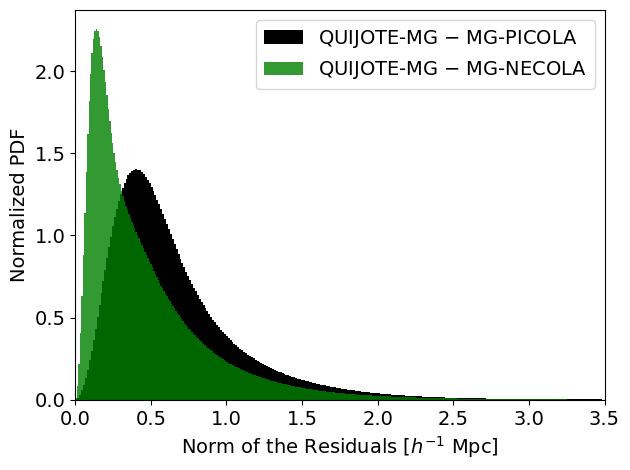

In [9]:
norm_residual_cola  = np.linalg.norm(residual_cola, axis=1)
norm_residual_vnet  = np.linalg.norm(residual_vnet, axis=1)

plt.hist(norm_residual_cola, bins=1500, alpha=1, label=r"QUIJOTE-MG $-$ MG-PICOLA", color='black', density=True)
plt.hist(norm_residual_vnet, bins=1500, alpha=0.8, label=r"QUIJOTE-MG $-$ MG-NECOLA", color='green', density=True)

plt.xlim(0, 3.5)

plt.xlabel(r'Norm of the Residuals [$h^{-1}$ Mpc]', fontsize=14)
plt.ylabel('Normalized PDF', fontsize=14)

plt.tick_params(axis='both', which='major', labelsize=14)

plt.legend(fontsize=14)
plt.tight_layout()
plt.savefig("Residuals_PDF.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [10]:
print(np.max(norm_residual_cola), np.min(norm_residual_cola), np.mean(norm_residual_cola), np.std(norm_residual_cola))
print(np.max(norm_residual_vnet), np.min(norm_residual_vnet), np.mean(norm_residual_vnet), np.std(norm_residual_vnet))

19.11678440914614 0.001209259033203125 0.6669467134830697 0.4600661157294095
14.55708924544918 0.0003379927933836277 0.47274499807400433 0.4364405877585036


## $\mathrm{Power~Spectrum}$

In [1]:
import Pk_from_snaps as pkmod
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Model
model = 'fR_p'
# Realizations
realizations = [0, 12, 16, 19, 22, 27, 34, 37, 45, 55]
BoxSize = 1000
# Save espectra
Pk_quij_all = []
Pk_cola_all = []
Pk_vnet_all = []
k_ref = None  # k-vector

In [3]:
for realization in realizations:
    print(f"Processing realization {realization}...")

    # --- Paths ---
    root_quijote = f'/data/jborjuel/data/Snapshots/{model}'
    path_ICs_quij = f"{root_quijote}/{realization}/ICs/ics"
    path_snaps_quij = f"{root_quijote}/{realization}/snapdir_004/snap_004"

    root_cola = f'/data/jborjuel/sims/fR/{model}/'
    path_ICs_cola = f"{root_cola}/{model}_{realization}/{model}_{realization}_z127p000"
    path_snaps_cola = f"{root_cola}/{model}_{realization}/{model}_{realization}_z0p000"

    # --- Positions ---
    pos_i_cola, pos_f_cola = pkmod.sort_pos(path_ICs_cola, path_snaps_cola, Quijote=False)
    pos_i_quij, pos_f_quij = pkmod.sort_pos(path_ICs_quij, path_snaps_quij, Quijote=True)

    # --- VNet Displacements ---
    path_vnet = f'/data/mrhurtad/bayron-proj/tests_m2m/bpT/sp_all/vnet_orig/vnet_{model}_{realization}.npy'
    disp_vnet = np.load(path_vnet).reshape(3, -1).T

    # --- VNet Positions ---
    pos_f_vnet = ((disp_vnet + pos_i_cola) % BoxSize).astype(np.float32)

    # --- Power Espectra ---
    k_quij, Pk_quij = pkmod.Pk(positions=pos_f_quij.astype(np.float32), Quijote=False)
    k_cola, Pk_cola = pkmod.Pk(positions=pos_f_cola.astype(np.float32), Quijote=False)
    k_vnet, Pk_vnet = pkmod.Pk(positions=pos_f_vnet, Quijote=False)

    # --- Common k-vector ---
    if k_ref is None:
        k_ref = k_quij  # They share the same grid
    else:
        # If not, interpolate
        if not (np.allclose(k_quij, k_ref) and np.allclose(k_cola, k_ref) and np.allclose(k_vnet, k_ref)):
            from scipy.interpolate import interp1d
            Pk_quij = interp1d(k_quij, Pk_quij, bounds_error=False, fill_value="extrapolate")(k_ref)
            Pk_cola = interp1d(k_cola, Pk_cola, bounds_error=False, fill_value="extrapolate")(k_ref)
            Pk_vnet = interp1d(k_vnet, Pk_vnet, bounds_error=False, fill_value="extrapolate")(k_ref)

    # --- Save spectra ---
    Pk_quij_all.append(Pk_quij)
    Pk_cola_all.append(Pk_cola)
    Pk_vnet_all.append(Pk_vnet)

# --- Convert to arrays ---
Pk_quij_all = np.array(Pk_quij_all)
Pk_cola_all = np.array(Pk_cola_all)
Pk_vnet_all = np.array(Pk_vnet_all)

# --- Averages ---
Pk_quij_mean = np.mean(Pk_quij_all, axis=0)
Pk_cola_mean = np.mean(Pk_cola_all, axis=0)
Pk_vnet_mean = np.mean(Pk_vnet_all, axis=0)

# --- Standard Deviations ---
Pk_quij_std = np.std(Pk_quij_all, axis=0)
Pk_cola_std = np.std(Pk_cola_all, axis=0)
Pk_vnet_std = np.std(Pk_vnet_all, axis=0)

Processing realization 0...
Processing realization 12...
Processing realization 16...
Processing realization 19...
Processing realization 22...
Processing realization 27...
Processing realization 34...
Processing realization 37...
Processing realization 45...
Processing realization 55...


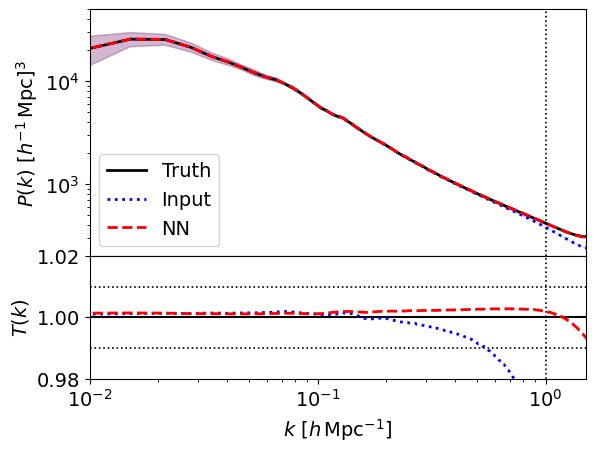

In [6]:
# Create figure
fig, axes = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [2, 1]})

####################################################
axes[0].set_ylabel(r'$P(k)\ [h^{-1}\,{\rm Mpc}]^3$', fontsize=14)
axes[0].set_xlim(1e-2, 1.5)
axes[0].set_ylim(2e2, 5e4)
axes[0].loglog(k_ref, Pk_quij_mean, linestyle='-', lw=2, color='black', label='Truth')
axes[0].fill_between(k_ref, Pk_quij_mean - Pk_quij_std, Pk_quij_mean + Pk_quij_std,
                 color='black', alpha=0.1, zorder=1, rasterized=True)
axes[0].loglog(k_ref, Pk_cola_mean, linestyle=':', lw=2, color='blue', label='Input')
axes[0].fill_between(k_ref, Pk_cola_mean - Pk_cola_std, Pk_cola_mean + Pk_cola_std,
                 color='blue', alpha=0.1, zorder=1, rasterized=True)
axes[0].loglog(k_ref, Pk_vnet_mean, linestyle='--', lw=2, color='red', label='NN')
axes[0].fill_between(k_ref, Pk_vnet_mean - Pk_vnet_std, Pk_vnet_mean + Pk_vnet_std,
                 color='red', alpha=0.1, zorder=1, rasterized=True)
axes[0].axvline(1.0, color='black', lw=1.2, ls=':')
axes[0].tick_params(axis='both', which='major', labelsize=14)
axes[0].legend(loc='lower left', fontsize=14)

####################################################
axes[1].set_xlim(1e-2, 1.5)
axes[1].set_ylim(0.98, 1.02)
axes[1].set_xlabel(r'$k\ [h\,{\rm Mpc}^{-1}]$', fontsize=14)
axes[1].set_ylabel(r'$T(k)$', fontsize=14)
axes[1].semilogx(k_ref, np.ones(len(k_ref)), '-', color='black')
axes[1].semilogx(k_ref, np.sqrt(Pk_cola_mean/Pk_quij_mean), linestyle=':', lw=2, color='blue')
axes[1].semilogx(k_ref, np.sqrt(Pk_vnet_mean/Pk_quij_mean), linestyle='--', lw=2, color='red')
axes[1].axvline(1.0, color='black', lw=1.2, ls=':')
axes[1].axhline(1.01, color='k', lw=1.2, ls=':')
axes[1].axhline(0.99, color='k', lw=1.2, ls=':')
axes[1].tick_params(axis='both', which='major', labelsize=14)

####################################################
plt.subplots_adjust(hspace=0)
plt.savefig("Pk.pdf", format="pdf", bbox_inches="tight")
plt.show()

# $\mathrm{Extrapolation}$

## $f(R)$

### `fRemu_p`

In [25]:
import Pk_from_snaps as pkmod
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

In [26]:
BoxSize = 1000

In [27]:
# Paths for COLA
root_cola = '/data/jborjuel/sims/fR/fRemu_p'
path_ICs_cola = f"{root_cola}/fRemu_p_z127p000"
path_snaps_cola = f"{root_cola}/fRemu_p_z0p000"

# Load positions
pos_i_cola, pos_f_cola = pkmod.sort_pos(path_ICs_cola, path_snaps_cola, Quijote=False)

# Compute power spectra
k_cola, Pk_cola = pkmod.Pk(positions=pos_f_cola.astype(np.float32), Quijote=False)

interp_Pk_cola = interp1d(
    np.log(k_cola),
    np.log(Pk_cola),
    kind="cubic",
    bounds_error=False,
    fill_value="extrapolate"
)

def Pk_cola(k_new):
    return np.exp(interp_Pk_cola(np.log(k_new)))

In [28]:
# Load VNet correction for fRemu_p
path_vnet_MG = f'/data/mrhurtad/bayron-proj/tests_m2m/bpT/MG-SRNet/vnet_fRemu_p.npy'
disp_vnet_MG = np.load(path_vnet_MG).reshape(3, -1).T

# Compute final position
pos_f_vnet_MG = ((disp_vnet_MG + pos_i_cola) % BoxSize).astype(np.float32)

# Compute spectrum
k, Pk_MG = pkmod.Pk(positions=pos_f_vnet_MG, Quijote=False)

interp_Pk_vnet = interp1d(
    np.log(k),
    np.log(Pk_MG),
    kind="cubic",
    bounds_error=False,
    fill_value="extrapolate"
)

def Pk_vnet(k_new):
    return np.exp(interp_Pk_vnet(np.log(k_new)))

In [29]:
k_fRemu, Pk_fRemu_data = np.loadtxt("fRemu_p.txt", unpack=True)

interp_Pk_fRemu = interp1d(
    np.log(k_fRemu),
    np.log(Pk_fRemu_data),
    kind="cubic",
    bounds_error=False,
    fill_value="extrapolate"
)

def Pk_fRemu(k_new):
    return np.exp(interp_Pk_fRemu(np.log(k_new)))

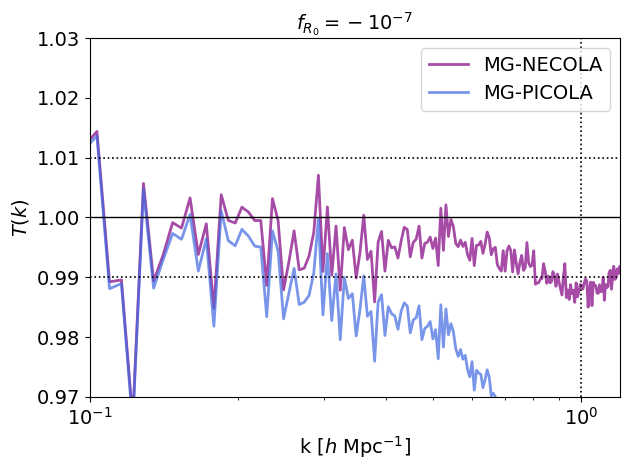

In [54]:
plt.xlim(0.1, 1.2)
plt.ylim(0.97, 1.03)

plt.semilogx(k_fRemu, np.sqrt(Pk_vnet(k_fRemu)/Pk_fRemu(k_fRemu)), '-', lw=2, color="purple", alpha=0.7, label="MG-NECOLA")
plt.semilogx(k_fRemu, np.sqrt(Pk_cola(k_fRemu)/Pk_fRemu(k_fRemu)), '-', lw=2, color="royalblue", alpha=0.7, label="MG-PICOLA")
plt.axvline(1.00, color='black', lw=1.2, ls=':')
plt.axhline(1.01, color='black', lw=1.2, ls=':')
plt.axhline(1.00, color='black', lw=1., ls='-')
plt.axhline(0.99, color='black', lw=1.2, ls=':')

plt.title(r"$f_{R_0} = -10^{-7}$", fontsize=14)
plt.xlabel(r'k [$h$ Mpc$^{-1}$]', fontsize=14)
plt.ylabel(r'$T(k)$', fontsize=14)

plt.tick_params(axis='both', which='major', labelsize=14)
plt.legend(loc="upper right", fontsize=14)
plt.tight_layout()
plt.savefig("fRemu_p.pdf", format="pdf", bbox_inches="tight")
plt.show()

### `fRemu_pp`

In [7]:
import Pk_from_snaps as pkmod
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

In [8]:
BoxSize = 1000

In [55]:
# Paths for COLA
root_cola = '/data/jborjuel/sims/fR/fRemu_pp'
path_ICs_cola = f"{root_cola}/fRemu_pp_z127p000"
path_snaps_cola = f"{root_cola}/fRemu_pp_z0p000"

# Load positions
pos_i_cola, pos_f_cola = pkmod.sort_pos(path_ICs_cola, path_snaps_cola, Quijote=False)

# Compute power spectra
k_cola, Pk_cola = pkmod.Pk(positions=pos_f_cola.astype(np.float32), Quijote=False)

interp_Pk_cola = interp1d(
    np.log(k_cola),
    np.log(Pk_cola),
    kind="cubic",
    bounds_error=False,
    fill_value="extrapolate"
)

def Pk_cola(k_new):
    return np.exp(interp_Pk_cola(np.log(k_new)))

In [56]:
# Load VNet correction for lcdm
path_vnet_MG = f'/data/mrhurtad/bayron-proj/tests_m2m/bpT/MG-SRNet/vnet_fRemu_pp.npy'
disp_vnet_MG = np.load(path_vnet_MG).reshape(3, -1).T

# Compute final position
pos_f_vnet_MG = ((disp_vnet_MG + pos_i_cola) % BoxSize).astype(np.float32)

# Compute spectrum
k, Pk_MG = pkmod.Pk(positions=pos_f_vnet_MG, Quijote=False)

interp_Pk_vnet = interp1d(
    np.log(k),
    np.log(Pk_MG),
    kind="cubic",
    bounds_error=False,
    fill_value="extrapolate"
)

def Pk_vnet(k_new):
    return np.exp(interp_Pk_vnet(np.log(k_new)))

In [57]:
k_fRemu, Pk_fRemu_data = np.loadtxt("fRemu_pp.txt", unpack=True)

interp_Pk_fRemu = interp1d(
    np.log(k_fRemu),
    np.log(Pk_fRemu_data),
    kind="cubic",
    bounds_error=False,
    fill_value="extrapolate"
)

def Pk_fRemu(k_new):
    return np.exp(interp_Pk_fRemu(np.log(k_new)))

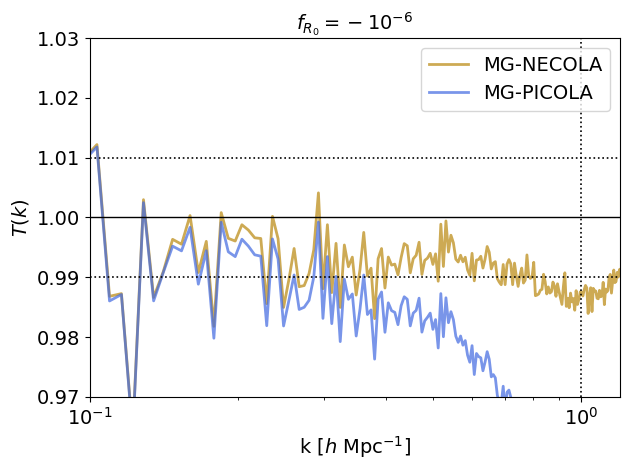

In [61]:
plt.xlim(0.1, 1.2)
plt.ylim(0.97, 1.03)

plt.semilogx(k_fRemu, np.sqrt(Pk_vnet(k_fRemu)/Pk_fRemu(k_fRemu)), '-', lw=2, color="darkgoldenrod", alpha=0.7, label="MG-NECOLA")
plt.semilogx(k_fRemu, np.sqrt(Pk_cola(k_fRemu)/Pk_fRemu(k_fRemu)), '-', lw=2, color="royalblue", alpha=0.7, label="MG-PICOLA")
plt.axvline(1.00, color='black', lw=1.2, ls=':')
plt.axhline(1.01, color='black', lw=1.2, ls=':')
plt.axhline(1.00, color='black', lw=1., ls='-')
plt.axhline(0.99, color='black', lw=1.2, ls=':')

plt.title(r"$f_{R_0} = -10^{-6}$", fontsize=14)
plt.xlabel(r'k [$h$ Mpc$^{-1}$]', fontsize=14)
plt.ylabel(r'$T(k)$', fontsize=14)

plt.tick_params(axis='both', which='major', labelsize=14)
plt.legend(loc="upper right", fontsize=14)
plt.tight_layout()
plt.savefig("fRemu_pp.pdf", format="pdf", bbox_inches="tight")
plt.show()

### `fRemu_ppp`

In [13]:
import Pk_from_snaps as pkmod
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

In [14]:
BoxSize = 1000

In [62]:
# Paths for COLA
root_cola = '/data/jborjuel/sims/fR/fRemu_ppp'
path_ICs_cola = f"{root_cola}/fRemu_ppp_z127p000"
path_snaps_cola = f"{root_cola}/fRemu_ppp_z0p000"

# Load positions
pos_i_cola, pos_f_cola = pkmod.sort_pos(path_ICs_cola, path_snaps_cola, Quijote=False)

# Compute power spectra
k_cola, Pk_cola = pkmod.Pk(positions=pos_f_cola.astype(np.float32), Quijote=False)

interp_Pk_cola = interp1d(
    np.log(k_cola),
    np.log(Pk_cola),
    kind="cubic",
    bounds_error=False,
    fill_value="extrapolate"
)

def Pk_cola(k_new):
    return np.exp(interp_Pk_cola(np.log(k_new)))

In [63]:
# Load VNet correction for fRemu_ppp
path_vnet_MG = f'/data/mrhurtad/bayron-proj/tests_m2m/bpT/MG-SRNet/vnet_fRemu_ppp.npy'
disp_vnet_MG = np.load(path_vnet_MG).reshape(3, -1).T

# Compute final position
pos_f_vnet_MG = ((disp_vnet_MG + pos_i_cola) % BoxSize).astype(np.float32)

# Compute spectrum
k, Pk_MG = pkmod.Pk(positions=pos_f_vnet_MG, Quijote=False)

interp_Pk_vnet = interp1d(
    np.log(k),
    np.log(Pk_MG),
    kind="cubic",
    bounds_error=False,
    fill_value="extrapolate"
)

def Pk_vnet(k_new):
    return np.exp(interp_Pk_vnet(np.log(k_new)))

In [64]:
k_fRemu, Pk_fRemu_data = np.loadtxt("fRemu_ppp.txt", unpack=True)

interp_Pk_fRemu = interp1d(
    np.log(k_fRemu),
    np.log(Pk_fRemu_data),
    kind="cubic",
    bounds_error=False,
    fill_value="extrapolate"
)

def Pk_fRemu(k_new):
    return np.exp(interp_Pk_fRemu(np.log(k_new)))

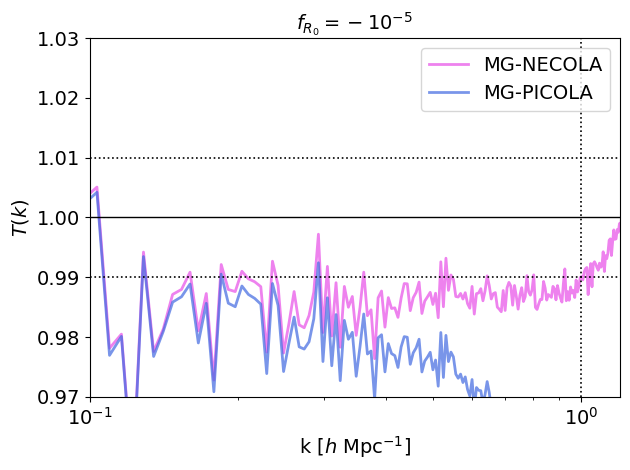

In [67]:
plt.xlim(0.1, 1.2)
plt.ylim(0.97, 1.03)

plt.semilogx(k_fRemu, np.sqrt(Pk_vnet(k_fRemu)/Pk_fRemu(k_fRemu)), '-', lw=2, color="violet", alpha=1, label="MG-NECOLA")
plt.semilogx(k_fRemu, np.sqrt(Pk_cola(k_fRemu)/Pk_fRemu(k_fRemu)), '-', lw=2, color="royalblue", alpha=0.7, label="MG-PICOLA")
plt.axvline(1.00, color='black', lw=1.2, ls=':')
plt.axhline(1.01, color='black', lw=1.2, ls=':')
plt.axhline(1.00, color='black', lw=1., ls='-')
plt.axhline(0.99, color='black', lw=1.2, ls=':')

plt.title(r"$f_{R_0} = -10^{-5}$", fontsize=14)
plt.xlabel(r'k [$h$ Mpc$^{-1}$]', fontsize=14)
plt.ylabel(r'$T(k)$', fontsize=14)

plt.tick_params(axis='both', which='major', labelsize=14)
plt.legend(loc="upper right", fontsize=14)
plt.tight_layout()
plt.savefig("fRemu_ppp.pdf", format="pdf", bbox_inches="tight")
plt.show()

### `fRemu_pppp`

In [19]:
import Pk_from_snaps as pkmod
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

In [20]:
BoxSize = 1000

In [68]:
# Paths for COLA
root_cola = '/data/jborjuel/sims/fR/fRemu_pppp'
path_ICs_cola = f"{root_cola}/fRemu_pppp_z127p000"
path_snaps_cola = f"{root_cola}/fRemu_pppp_z0p000"

# Load positions
pos_i_cola, pos_f_cola = pkmod.sort_pos(path_ICs_cola, path_snaps_cola, Quijote=False)

# Compute power spectra
k_cola, Pk_cola = pkmod.Pk(positions=pos_f_cola.astype(np.float32), Quijote=False)

interp_Pk_cola = interp1d(
    np.log(k_cola),
    np.log(Pk_cola),
    kind="cubic",
    bounds_error=False,
    fill_value="extrapolate"
)

def Pk_cola(k_new):
    return np.exp(interp_Pk_cola(np.log(k_new)))

In [69]:
# Load VNet correction for fRemu_pppp
path_vnet_MG = f'/data/mrhurtad/bayron-proj/tests_m2m/bpT/MG-SRNet/vnet_fRemu_pppp.npy'
disp_vnet_MG = np.load(path_vnet_MG).reshape(3, -1).T

# Compute final position
pos_f_vnet_MG = ((disp_vnet_MG + pos_i_cola) % BoxSize).astype(np.float32)

# Compute spectrum
k, Pk_MG = pkmod.Pk(positions=pos_f_vnet_MG, Quijote=False)

interp_Pk_vnet = interp1d(
    np.log(k),
    np.log(Pk_MG),
    kind="cubic",
    bounds_error=False,
    fill_value="extrapolate"
)

def Pk_vnet(k_new):
    return np.exp(interp_Pk_vnet(np.log(k_new)))

In [70]:
k_fRemu, Pk_fRemu_data = np.loadtxt("fRemu_pppp.txt", unpack=True)

interp_Pk_fRemu = interp1d(
    np.log(k_fRemu),
    np.log(Pk_fRemu_data),
    kind="cubic",
    bounds_error=False,
    fill_value="extrapolate"
)

def Pk_fRemu(k_new):
    return np.exp(interp_Pk_fRemu(np.log(k_new)))

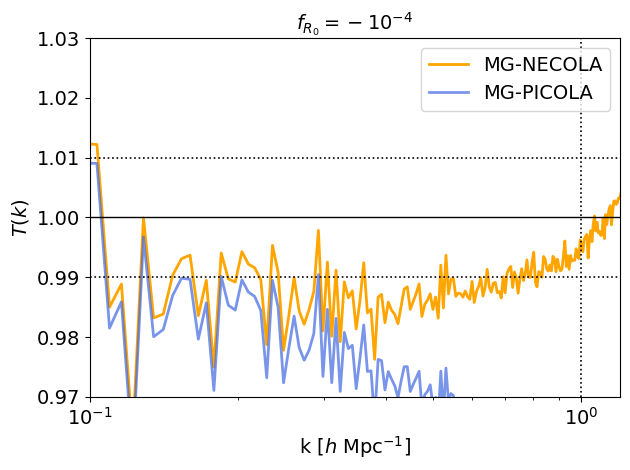

In [72]:
plt.xlim(0.1, 1.2)
plt.ylim(0.97, 1.03)

plt.semilogx(k_fRemu, np.sqrt(Pk_vnet(k_fRemu)/Pk_fRemu(k_fRemu)), '-', lw=2, color="orange", alpha=1, label="MG-NECOLA")
plt.semilogx(k_fRemu, np.sqrt(Pk_cola(k_fRemu)/Pk_fRemu(k_fRemu)), '-', lw=2, color="royalblue", alpha=0.7, label="MG-PICOLA")
plt.axvline(1.00, color='black', lw=1.2, ls=':')
plt.axhline(1.01, color='black', lw=1.2, ls=':')
plt.axhline(1.00, color='black', lw=1., ls='-')
plt.axhline(0.99, color='black', lw=1.2, ls=':')

plt.title(r"$f_{R_0} = -10^{-4}$", fontsize=14)
plt.xlabel(r'k [$h$ Mpc$^{-1}$]', fontsize=14)
plt.ylabel(r'$T(k)$', fontsize=14)

plt.tick_params(axis='both', which='major', labelsize=14)
plt.legend(loc="upper right", fontsize=14)
plt.tight_layout()
plt.savefig("fRemu_pppp.pdf", format="pdf", bbox_inches="tight")
plt.show()

## $\Lambda\mathrm{CDM}$

In [1]:
import Pk_from_snaps as pkmod
import numpy as np
import matplotlib.pyplot as plt

In [2]:
realization = 0
BoxSize = 1000

In [3]:
# Paths for Quijote
root_quijote = f'/data/jborjuel/data/fiducial'
path_ICs_quij = f"{root_quijote}/{realization}/ICs/ics"
path_snaps_quij = f"{root_quijote}/{realization}/snapdir_004/snap_004"

# Paths for COLA
root_cola = f'/data/jborjuel/sims/lcdm'
path_ICs_cola = f"{root_cola}/{realization}/lcdm__z127p000"
path_snaps_cola = f"{root_cola}/{realization}/lcdm__z0p000"

# Load positions
pos_i_cola, pos_f_cola = pkmod.sort_pos(path_ICs_cola, path_snaps_cola, Quijote=False)
pos_i_quij, pos_f_quij = pkmod.sort_pos(path_ICs_quij, path_snaps_quij, Quijote=True)

# Compute power spectra
k_quij, Pk_quij = pkmod.Pk(positions=pos_f_quij.astype(np.float32), Quijote=False)
k_cola, Pk_cola = pkmod.Pk(positions=pos_f_cola.astype(np.float32), Quijote=False)

In [4]:
# Load VNet correction for lcdm
path_vnet_MG = f'/data/mrhurtad/bayron-proj/tests_m2m/bpT/MG-SRNet/vnet_lcdm_{realization}.npy'
disp_vnet_MG = np.load(path_vnet_MG).reshape(3, -1).T

# Compute final position
pos_f_vnet_MG = ((disp_vnet_MG + pos_i_cola) % BoxSize).astype(np.float32)

# Compute spectrum
k, Pk_MG = pkmod.Pk(positions=pos_f_vnet_MG, Quijote=False)

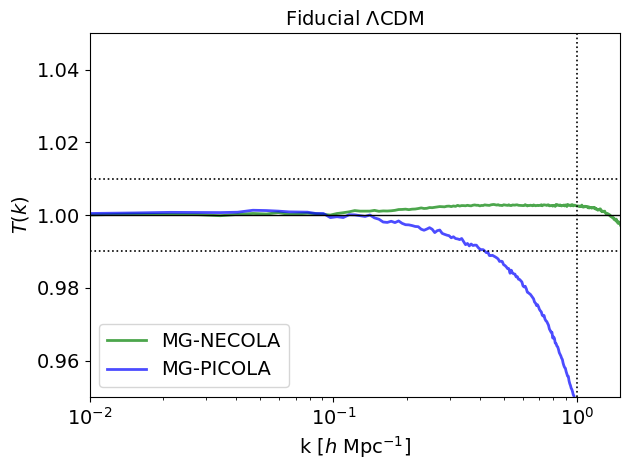

In [5]:
plt.xlim(1e-2, 1.5)
plt.ylim(0.95, 1.05)

plt.semilogx(k, np.sqrt(Pk_MG/Pk_quij), lw=2, color='green', alpha=0.7, label="MG-NECOLA")
plt.semilogx(k, np.sqrt(Pk_cola/Pk_quij), lw=2, color='blue', alpha=0.7, label="MG-PICOLA")
plt.axvline(1.00, color='black', lw=1.2, ls=':')
plt.axhline(1.01, color='black', lw=1.2, ls=':')
plt.axhline(1.00, color='black', lw=1., ls='-')
plt.axhline(0.99, color='black', lw=1.2, ls=':')

plt.title(r"Fiducial $\Lambda$CDM", fontsize=14)
plt.xlabel(r'k [$h$ Mpc$^{-1}$]', fontsize=14)
plt.ylabel(r'$T(k)$', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.legend(loc="lower left", fontsize=14)
plt.tight_layout()
plt.savefig("LCDM.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [6]:
acc_MG = np.mean(np.abs(1 - (Pk_MG[0:238] / Pk_quij[0:238]))*100)
acc_cola = np.mean(np.abs(1 - (Pk_cola[0:238] / Pk_quij[0:238]))*100)
acc_MG, acc_cola

(0.40054680694931605, 7.974184496787617)

## $M_\nu^+$

In [1]:
import Pk_from_snaps as pkmod
import numpy as np
import matplotlib.pyplot as plt

In [2]:
BoxSize = 1000

In [7]:
# Paths for Quijote
root_quijote = '/data/jborjuel/data/Snapshots/Mnu_p/0'
path_ICs_quij = f"{root_quijote}/ICs/ics"
path_snaps_quij = f"{root_quijote}/snapdir_004/snap_004"

# Paths for COLA
root_cola = '/data/jborjuel/sims/Mnu/Mnup'
path_ICs_cola = f"{root_cola}/mg_Mnup_z127p000"
path_snaps_cola = f"{root_cola}/mg_Mnup_z0p000"

# Load positions
pos_i_cola, pos_f_cola = pkmod.sort_pos(path_ICs_cola, path_snaps_cola, Quijote=False)
pos_i_quij, pos_f_quij = pkmod.sort_pos(path_ICs_quij, path_snaps_quij, Quijote=True)

# Compute power spectra
k_quij, Pk_quij = pkmod.Pk(positions=pos_f_quij.astype(np.float32), Quijote=False)
k_cola, Pk_cola = pkmod.Pk(positions=pos_f_cola.astype(np.float32), Quijote=False)

In [8]:
# Load VNet correction for Mnu_p
path_vnet_MG = '/data/mrhurtad/bayron-proj/tests_m2m/bpT/MG-SRNet/vnet_Mnu_p_0.npy'
disp_vnet_MG = np.load(path_vnet_MG).reshape(3, -1).T

# Compute final positions
pos_f_vnet_MG = ((disp_vnet_MG + pos_i_cola) % BoxSize).astype(np.float32)

# Compute spectra
k, Pk_MG = pkmod.Pk(positions=pos_f_vnet_MG, Quijote=False)

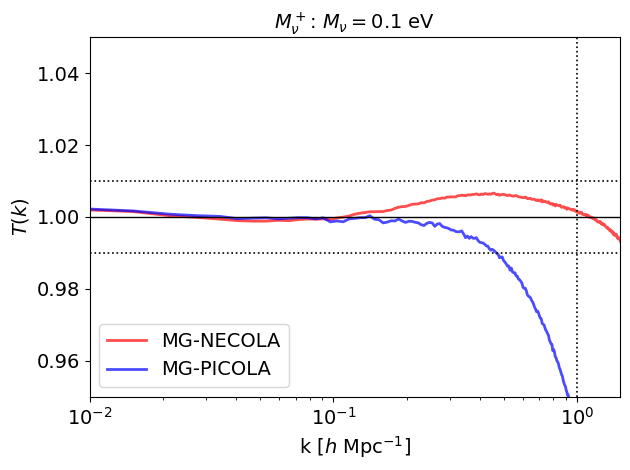

In [11]:
plt.xlim(1e-2, 1.5)
plt.ylim(0.95, 1.05)

plt.semilogx(k, np.sqrt(Pk_MG/Pk_quij), lw=2, color='red', alpha=0.7, label="MG-NECOLA")
plt.semilogx(k, np.sqrt(Pk_cola/Pk_quij), lw=2, color='blue', alpha=0.7, label="MG-PICOLA")
plt.axvline(1.00, color='black', lw=1.2, ls=':')
plt.axhline(1.01, color='black', lw=1.2, ls=':')
plt.axhline(1.00, color='black', lw=1., ls='-')
plt.axhline(0.99, color='black', lw=1.2, ls=':')

plt.title(r"$M_\nu^+$: $M_\nu = 0.1$ eV", fontsize=14)
plt.xlabel(r'k [$h$ Mpc$^{-1}$]', fontsize=14)
plt.ylabel(r'$T(k)$', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.legend(loc="lower left", fontsize=14)
plt.tight_layout()
plt.savefig("Mnu_p.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [10]:
acc_MG = np.mean(np.abs(1 - (Pk_MG[0:238] / Pk_quij[0:238]))*100)
acc_cola = np.mean(np.abs(1 - (Pk_cola[0:238] / Pk_quij[0:238]))*100)
acc_MG, acc_cola

(0.6798619950251193, 8.533372363435898)

## $M_\nu^{++}$

In [12]:
import Pk_from_snaps as pkmod
import numpy as np
import matplotlib.pyplot as plt

In [13]:
BoxSize = 1000

In [14]:
# Paths for Quijote
root_quijote = '/data/jborjuel/data/Snapshots/Mnu_pp/0'
path_ICs_quij = f"{root_quijote}/ICs/ics"
path_snaps_quij = f"{root_quijote}/snapdir_004/snap_004"

# Paths for COLA
root_cola = '/data/jborjuel/sims/Mnu/Mnupp'
path_ICs_cola = f"{root_cola}/mg_Mnupp_z127p000"
path_snaps_cola = f"{root_cola}/mg_Mnupp_z0p000"

# Load positions
pos_i_cola, pos_f_cola = pkmod.sort_pos(path_ICs_cola, path_snaps_cola, Quijote=False)
pos_i_quij, pos_f_quij = pkmod.sort_pos(path_ICs_quij, path_snaps_quij, Quijote=True)

# Compute power spectra
k_quij, Pk_quij = pkmod.Pk(positions=pos_f_quij.astype(np.float32), Quijote=False)
k_cola, Pk_cola = pkmod.Pk(positions=pos_f_cola.astype(np.float32), Quijote=False)

In [15]:
# Load VNet correction for Mnu_pp
path_vnet_MG = '/data/mrhurtad/bayron-proj/tests_m2m/bpT/MG-SRNet/vnet_Mnu_pp_0.npy'
disp_vnet_MG = np.load(path_vnet_MG).reshape(3, -1).T

# Compute final positions
pos_f_vnet_MG = ((disp_vnet_MG + pos_i_cola) % BoxSize).astype(np.float32)

# Compute spectrum
k, Pk_MG = pkmod.Pk(positions=pos_f_vnet_MG, Quijote=False)

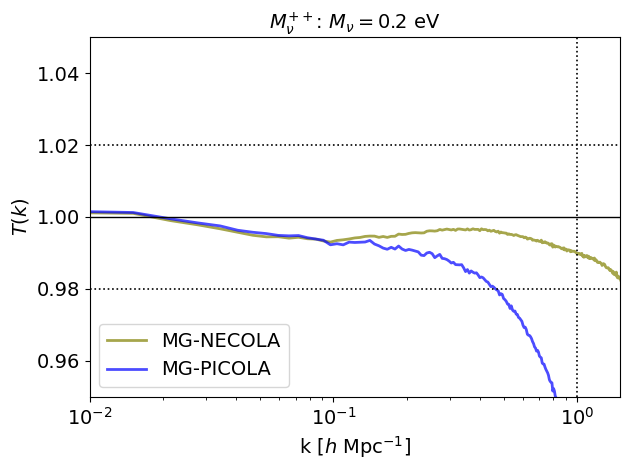

In [23]:
plt.xlim(1e-2, 1.5)
plt.ylim(0.95, 1.05)

plt.semilogx(k, np.sqrt(Pk_MG/Pk_quij), lw=2, color='olive', alpha=0.7, label="MG-NECOLA")
plt.semilogx(k, np.sqrt(Pk_cola/Pk_quij), lw=2, color='blue', alpha=0.7, label="MG-PICOLA")
plt.axvline(1.00, color='black', lw=1.2, ls=':')
plt.axhline(1.02, color='black', lw=1.2, ls=':')
plt.axhline(1.00, color='black', lw=1., ls='-')
plt.axhline(0.98, color='black', lw=1.2, ls=':')

plt.title(r"$M_\nu^{++}$: $M_\nu = 0.2$ eV", fontsize=14)
plt.xlabel(r'k [$h$ Mpc$^{-1}$]', fontsize=14)
plt.ylabel(r'$T(k)$', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.legend(loc="lower left", fontsize=14)
plt.tight_layout()
plt.savefig("Mnu_pp.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [24]:
acc_MG = np.mean(np.abs(1 - (Pk_MG[0:238] / Pk_quij[0:238]))*100)
acc_cola = np.mean(np.abs(1 - (Pk_cola[0:238] / Pk_quij[0:238]))*100)
acc_MG, acc_cola

(1.6406222393022354, 10.337933439231064)

## $M_\nu^{+++}$

In [25]:
import Pk_from_snaps as pkmod
import numpy as np
import matplotlib.pyplot as plt

In [26]:
BoxSize = 1000

In [27]:
# Paths for Quijote
root_quijote = '/data/jborjuel/data/Snapshots/Mnu_ppp/0'
path_ICs_quij = f"{root_quijote}/ICs/ics"
path_snaps_quij = f"{root_quijote}/snapdir_004/snap_004"

# Paths for COLA
root_cola = '/data/jborjuel/sims/Mnu/Mnuppp'
path_ICs_cola = f"{root_cola}/mg_Mnuppp_z127p000"
path_snaps_cola = f"{root_cola}/mg_Mnuppp_z0p000"

# Load positions
pos_i_cola, pos_f_cola = pkmod.sort_pos(path_ICs_cola, path_snaps_cola, Quijote=False)
pos_i_quij, pos_f_quij = pkmod.sort_pos(path_ICs_quij, path_snaps_quij, Quijote=True)

# Compute power spectra
k_quij, Pk_quij = pkmod.Pk(positions=pos_f_quij.astype(np.float32), Quijote=False)
k_cola, Pk_cola = pkmod.Pk(positions=pos_f_cola.astype(np.float32), Quijote=False)

In [28]:
# Load VNet correction for Mnu_ppp
path_vnet_MG = '/data/mrhurtad/bayron-proj/tests_m2m/bpT/MG-SRNet/vnet_Mnu_ppp_0.npy'
disp_vnet_MG = np.load(path_vnet_MG).reshape(3, -1).T

# Compute final positions
pos_f_vnet_MG = ((disp_vnet_MG + pos_i_cola) % BoxSize).astype(np.float32)

# Compute spectrum
k, Pk_MG = pkmod.Pk(positions=pos_f_vnet_MG, Quijote=False)

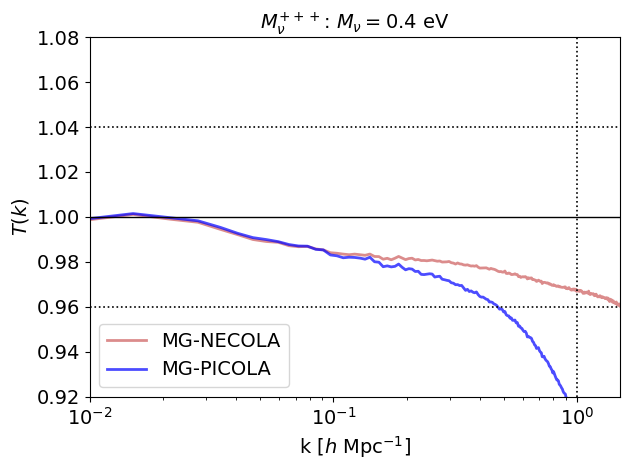

In [36]:
plt.xlim(1e-2, 1.5)
plt.ylim(0.92, 1.08)

plt.semilogx(k, np.sqrt(Pk_MG/Pk_quij), lw=2, color='indianred', alpha=0.7, label="MG-NECOLA")
plt.semilogx(k, np.sqrt(Pk_cola/Pk_quij), lw=2, color='blue', alpha=0.7, label="MG-PICOLA")
plt.axvline(1.00, color='black', lw=1.2, ls=':')
plt.axhline(1.04, color='black', lw=1.2, ls=':')
plt.axhline(1.00, color='black', lw=1., ls='-')
plt.axhline(0.96, color='black', lw=1.2, ls=':')

plt.title(r"$M_\nu^{+++}$: $M_\nu = 0.4$ eV", fontsize=14)
plt.xlabel(r'k [$h$ Mpc$^{-1}$]', fontsize=14)
plt.ylabel(r'$T(k)$', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.legend(loc="lower left", fontsize=14)
plt.tight_layout()
plt.savefig("Mnu_ppp.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [37]:
acc_MG = np.mean(np.abs(1 - (Pk_MG[0:238] / Pk_quij[0:238]))*100)
acc_cola = np.mean(np.abs(1 - (Pk_cola[0:238] / Pk_quij[0:238]))*100)
acc_MG, acc_cola

(5.45955384657477, 13.733279778277804)

## $f(R)+M_\nu$

In [1]:
import Pk_from_snaps as pkmod
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Realizations
realizations = [0, 1, 2]
BoxSize = 1000
# Save espectra
Pk_quij_all = []
Pk_cola_all = []
Pk_vnet_all = []
k_ref = None  # k-vector

In [3]:
for realization in realizations:
    print(f"Processing realization {realization}...")

    # --- Paths ---
    root_quijote = f'/data/QUIJOTE-MG/Snapshots/SB7'
    path_ICs_quij = f"{root_quijote}/{realization}/ICs/ics"
    path_snaps_quij = f"{root_quijote}/{realization}/snapdir_004/snap_004"

    root_cola = f'/data/jborjuel/sims/fofr_nu'
    path_ICs_cola = f"{root_cola}/mgcola_{realization}/snaps_mgcola_{realization}_z127p000"
    path_snaps_cola = f"{root_cola}/mgcola_{realization}/snaps_mgcola_{realization}_z0p000"

    # --- Positions ---
    pos_i_cola, pos_f_cola = pkmod.sort_pos(path_ICs_cola, path_snaps_cola, Quijote=False)
    pos_i_quij, pos_f_quij = pkmod.sort_pos(path_ICs_quij, path_snaps_quij, Quijote=True)

    # --- VNet Displacements ---
    path_vnet = f'/data/mrhurtad/bayron-proj/tests_m2m/bpT/MG-SRNet/vnet_fofr_nu_{realization}.npy'
    disp_vnet = np.load(path_vnet).reshape(3, -1).T

    # --- VNet Positions ---
    pos_f_vnet = ((disp_vnet + pos_i_cola) % BoxSize).astype(np.float32)

    # --- Power Espectra ---
    k_quij, Pk_quij = pkmod.Pk(positions=pos_f_quij.astype(np.float32), Quijote=False)
    k_cola, Pk_cola = pkmod.Pk(positions=pos_f_cola.astype(np.float32), Quijote=False)
    k_vnet, Pk_vnet = pkmod.Pk(positions=pos_f_vnet, Quijote=False)

    # --- Common k-vector ---
    if k_ref is None:
        k_ref = k_quij  # They share the same grid
    else:
        # If not, interpolate
        if not (np.allclose(k_quij, k_ref) and np.allclose(k_cola, k_ref) and np.allclose(k_vnet, k_ref)):
            from scipy.interpolate import interp1d
            Pk_quij = interp1d(k_quij, Pk_quij, bounds_error=False, fill_value="extrapolate")(k_ref)
            Pk_cola = interp1d(k_cola, Pk_cola, bounds_error=False, fill_value="extrapolate")(k_ref)
            Pk_vnet = interp1d(k_vnet, Pk_vnet, bounds_error=False, fill_value="extrapolate")(k_ref)

    # --- Save spectra ---
    Pk_quij_all.append(Pk_quij)
    Pk_cola_all.append(Pk_cola)
    Pk_vnet_all.append(Pk_vnet)

# --- Convert to arrays ---
Pk_quij_all = np.array(Pk_quij_all)
Pk_cola_all = np.array(Pk_cola_all)
Pk_vnet_all = np.array(Pk_vnet_all)

Processing realization 0...
Processing realization 1...
Processing realization 2...


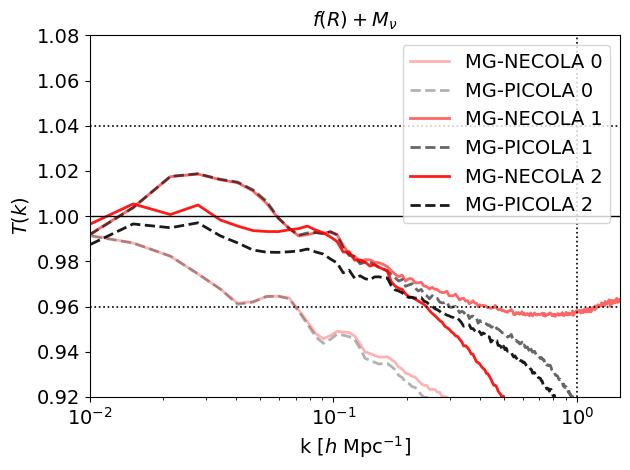

In [29]:
plt.xlim(1e-2, 1.5)
plt.ylim(0.92, 1.08)

for i in realizations:
    plt.semilogx(k_quij, np.sqrt(Pk_vnet_all[i]/Pk_quij_all[i]), lw=2, color='red', alpha=0.3*(1+i), label=f"MG-NECOLA {i}")
    plt.semilogx(k_quij, np.sqrt(Pk_cola_all[i]/Pk_quij_all[i]), '--', lw=2, color='black', alpha=0.3*(1+i), label=f"MG-PICOLA {i}")
plt.axvline(1.00, color='black', lw=1.2, ls=':')
plt.axhline(1.04, color='black', lw=1.2, ls=':')
plt.axhline(1.00, color='black', lw=1., ls='-')
plt.axhline(0.96, color='black', lw=1.2, ls=':')

plt.title(r"$f(R) + M_\nu$", fontsize=14)
plt.xlabel(r'k [$h$ Mpc$^{-1}$]', fontsize=14)
plt.ylabel(r'$T(k)$', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.legend(loc="upper right", fontsize=14)
plt.tight_layout()
#plt.savefig("Mnu_ppp.pdf", format="pdf", bbox_inches="tight")
plt.show()